In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv('House_train.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df.drop(
    columns=[
        'Id',
        'Alley',
        'PoolQC',
        'Fence',
        'MiscFeature',
        'MiscVal',
        'Condition2',
        'RoofMatl',
        'Utilities'
    ],
    inplace=True
)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 72 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   LotConfig      1460 non-null   object 
 8   LandSlope      1460 non-null   object 
 9   Neighborhood   1460 non-null   object 
 10  Condition1     1460 non-null   object 
 11  BldgType       1460 non-null   object 
 12  HouseStyle     1460 non-null   object 
 13  OverallQual    1460 non-null   int64  
 14  OverallCond    1460 non-null   int64  
 15  YearBuilt      1460 non-null   int64  
 16  YearRemodAdd   1460 non-null   int64  
 17  RoofStyle      1460 non-null   object 
 18  Exterior

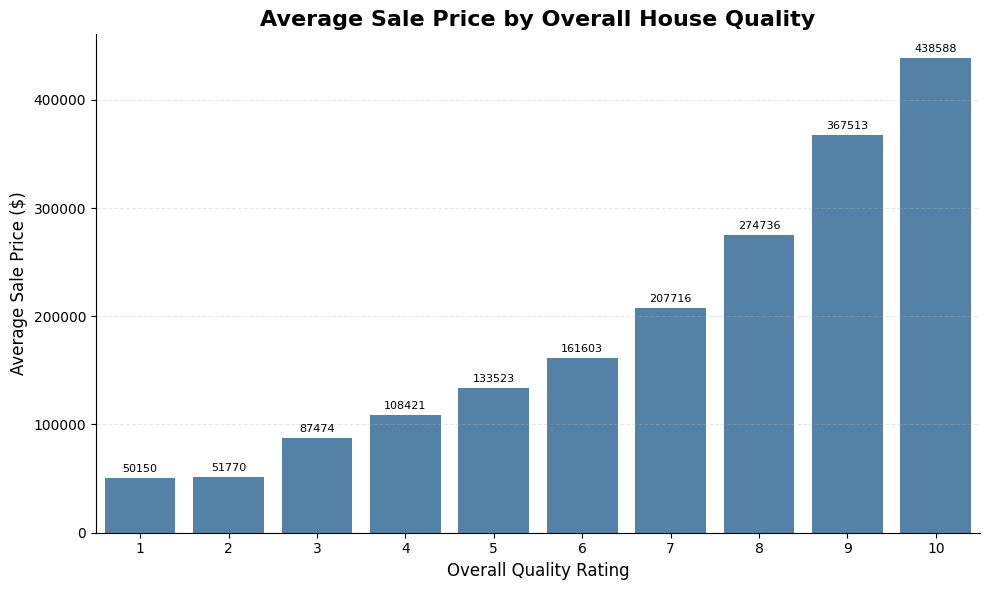

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df,
    x='OverallQual',
    y='SalePrice',
    estimator='mean',
    errorbar=None,
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=8,
        padding=3
    )

plt.title(
    'Average Sale Price by Overall House Quality',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Overall Quality Rating', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

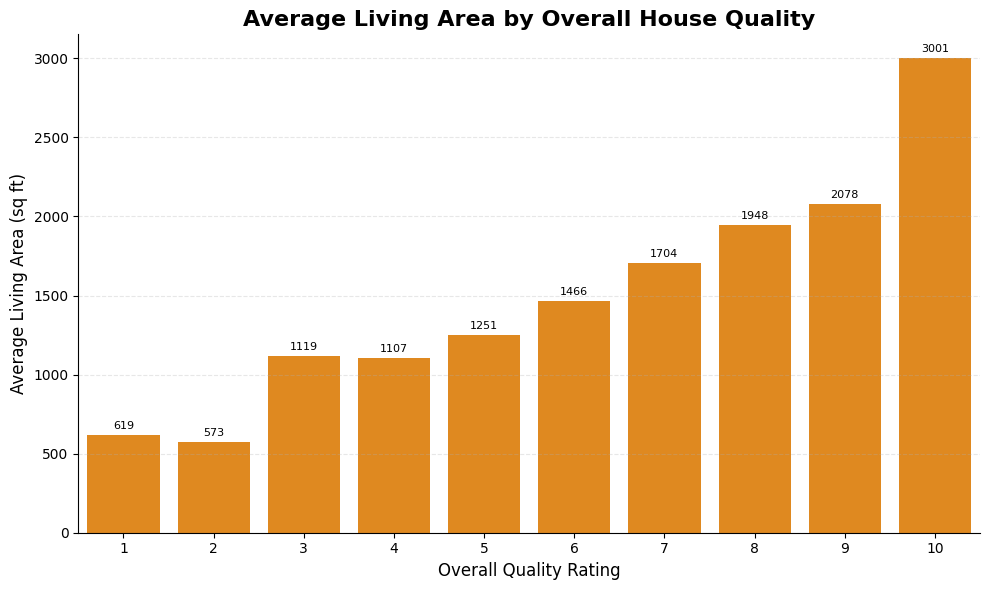

In [13]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df,
    x='OverallQual',
    y='GrLivArea',
    estimator='mean',
    errorbar=None,
    color='darkorange'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=8,
        padding=3
    )

plt.title(
    'Average Living Area by Overall House Quality',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Overall Quality Rating', fontsize=12)
plt.ylabel('Average Living Area (sq ft)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

### 💡 Insight 1: Higher Quality Houses Command Significantly Higher Selling Prices

**Observation:**

Houses with higher **Overall Quality** ratings consistently achieved higher average selling prices. The increase in price was gradual across the quality scale, with premium-quality houses (ratings **8–10**) commanding substantially higher prices than houses with average or below-average quality.

**Business Insight:**

The supporting analysis shows that higher-quality houses also have **larger average living areas**, indicating that premium properties not only offer superior construction quality and finishes but also provide more usable living space. This combination of better quality and larger size makes these properties more attractive to buyers, resulting in higher market values.

**Recommendation:**

Real estate developers should focus on improving **construction quality, interior finishes, and functional living space** to maximize property value. Homebuyers seeking long-term investment opportunities should prioritize **overall house quality**, as it is one of the strongest indicators of future resale value and market demand.

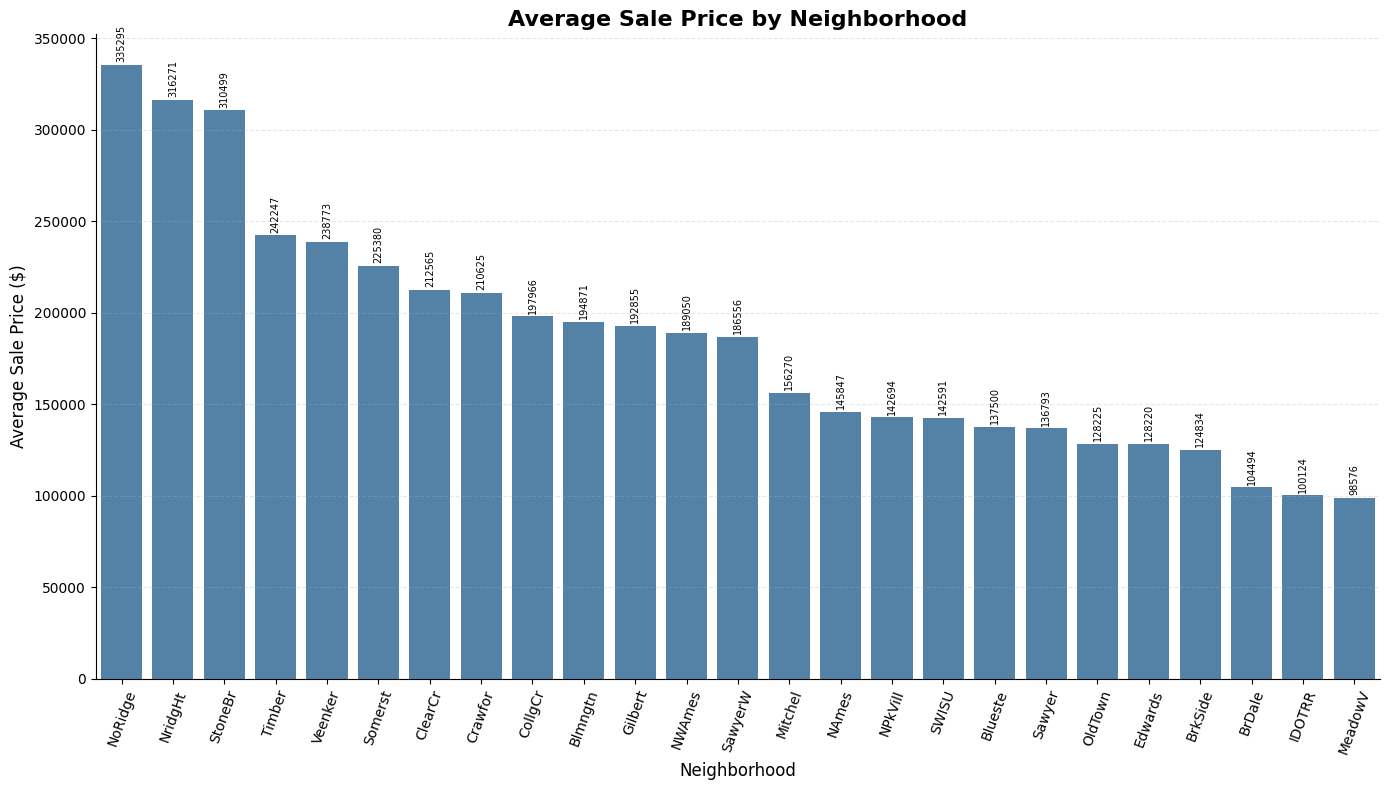

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=df,
    x='Neighborhood',
    y='SalePrice',
    estimator='mean',
    errorbar=None,
    color='steelblue',
    order=df.groupby('Neighborhood')['SalePrice']
            .mean()
            .sort_values(ascending=False)
            .index
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=7,
        rotation=90,
        padding=2
    )

plt.title(
    'Average Sale Price by Neighborhood',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)

plt.xticks(rotation=70)

plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

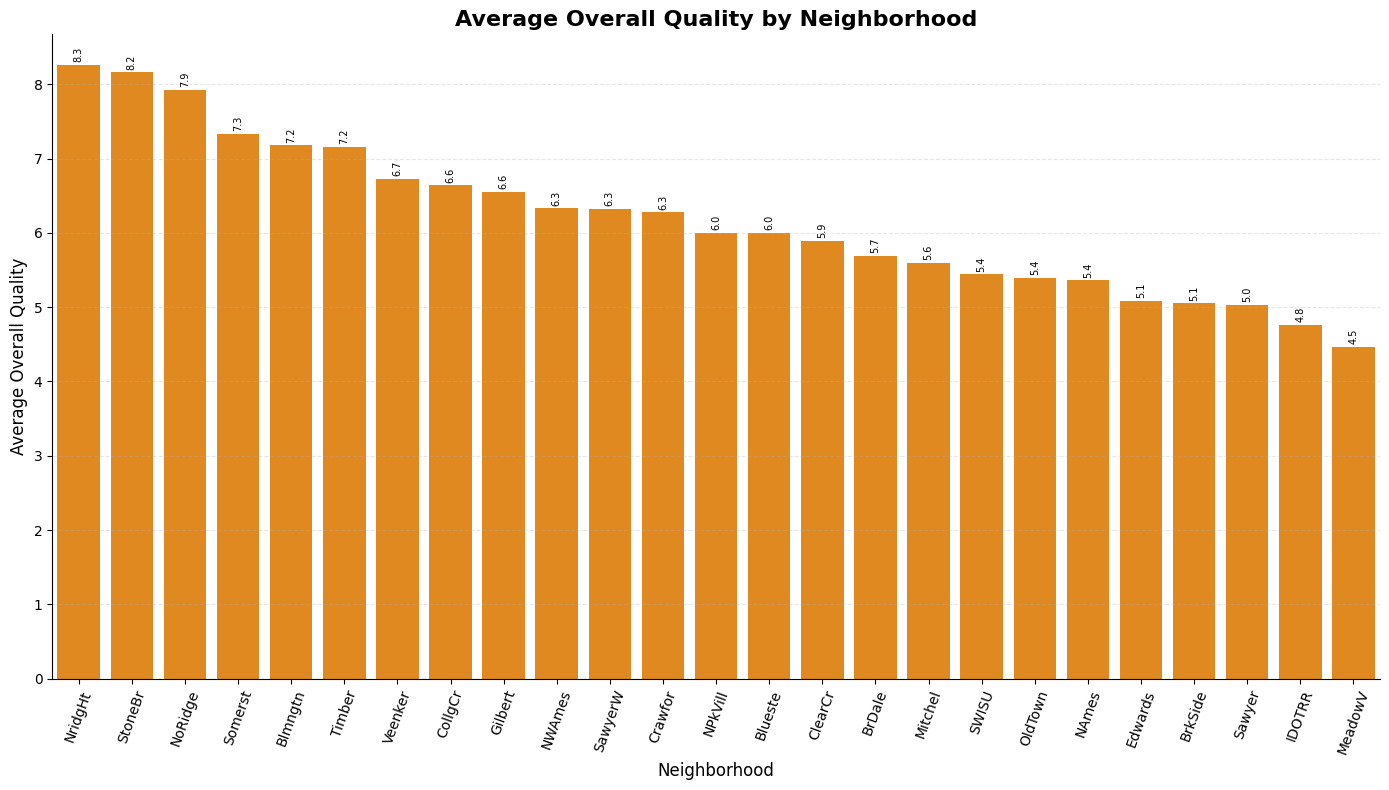

In [15]:
plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=df,
    x='Neighborhood',
    y='OverallQual',
    estimator='mean',
    errorbar=None,
    color='darkorange',
    order=df.groupby('Neighborhood')['OverallQual']
            .mean()
            .sort_values(ascending=False)
            .index
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        fontsize=7,
        rotation=90,
        padding=2
    )

plt.title(
    'Average Overall Quality by Neighborhood',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Average Overall Quality', fontsize=12)

plt.xticks(rotation=70)

plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

### 💡 Insight 2: Premium Neighborhoods Command Higher House Prices

**Observation:**

House prices varied considerably across neighborhoods, with premium neighborhoods consistently recording significantly higher average selling prices than other areas. This indicates that **location is one of the strongest factors influencing property value**.

**Business Insight:**

The supporting analysis shows that premium neighborhoods also have **higher average overall house quality**, suggesting that these areas generally contain better-constructed homes with superior finishes and amenities. Buyers are therefore willing to pay a premium not only for the location but also for the higher quality of properties available in these neighborhoods.

**Recommendation:**

Homebuyers should evaluate both **neighborhood** and **overall house quality** when making purchasing decisions. Real estate developers aiming to maximize property value should prioritize high-quality construction in desirable locations, as the combination of premium location and superior quality significantly increases market value.

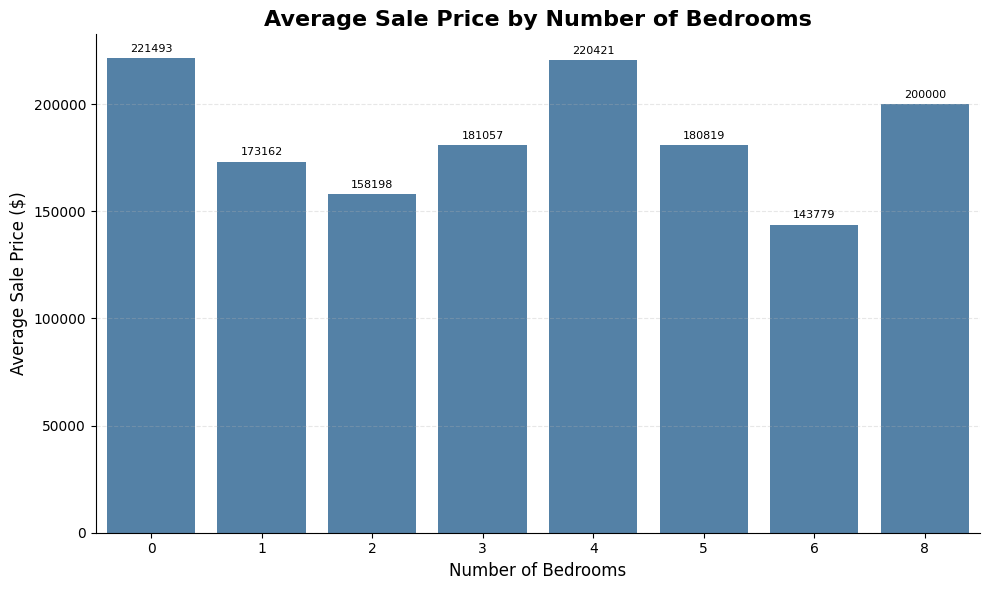

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df,
    x='BedroomAbvGr',
    y='SalePrice',
    estimator='mean',
    errorbar=None,
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=8,
        padding=3
    )

plt.title(
    'Average Sale Price by Number of Bedrooms',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

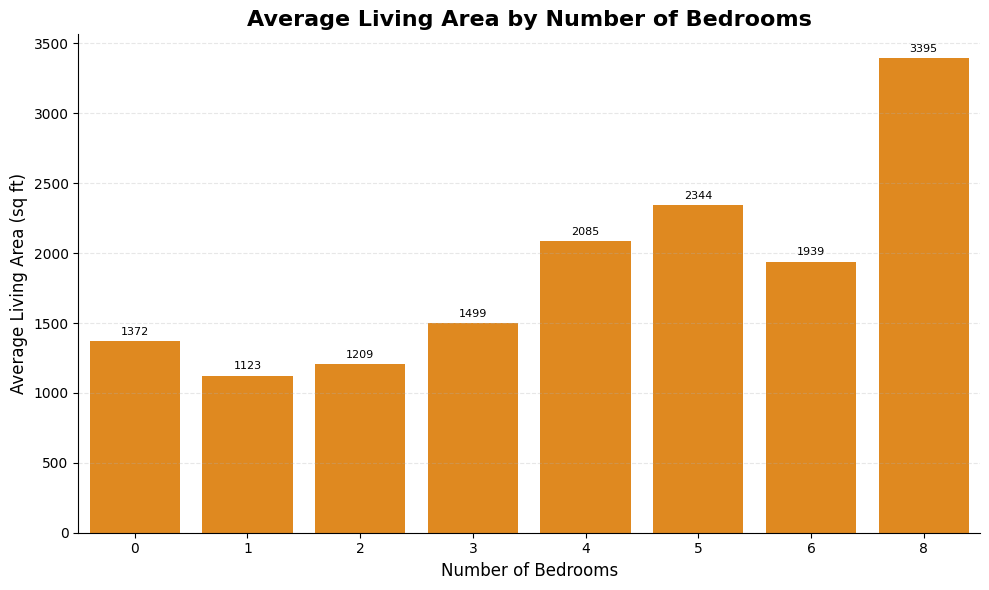

In [17]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df,
    x='BedroomAbvGr',
    y='GrLivArea',
    estimator='mean',
    errorbar=None,
    color='darkorange'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=8,
        padding=3
    )

plt.title(
    'Average Living Area by Number of Bedrooms',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Average Living Area (sq ft)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

### 💡 Insight 3: Houses with More Bedrooms Generally Achieve Higher Selling Prices

**Observation:**

The average selling price generally increased as the number of bedrooms increased, indicating that larger family homes tend to command higher market values. However, properties with an unusually high number of bedrooms should be interpreted cautiously, as they may represent a small number of luxury or uncommon homes.

**Business Insight:**

The supporting analysis shows that houses with more bedrooms also have **larger average living areas**, suggesting that buyers are paying not only for additional bedrooms but also for the increased usable space that accompanies them. Larger homes offer greater functionality for families, making them more desirable in the real estate market.

**Recommendation:**

Homebuyers should evaluate the **overall living area together with the number of bedrooms** when assessing a property's value. Real estate developers can increase property appeal by designing homes that balance bedroom count with spacious and functional living areas rather than simply adding more rooms.

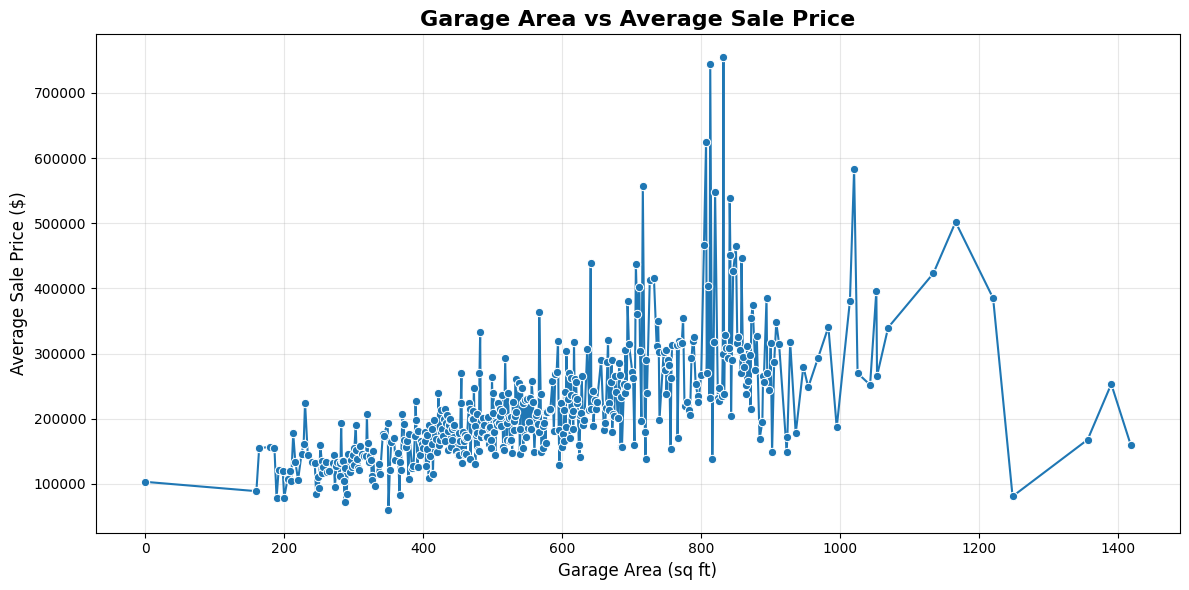

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

garage_price = (
    df.groupby('GarageArea')['SalePrice']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=garage_price,
    x='GarageArea',
    y='SalePrice',
    marker='o'
)

plt.title(
    'Garage Area vs Average Sale Price',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Garage Area (sq ft)', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

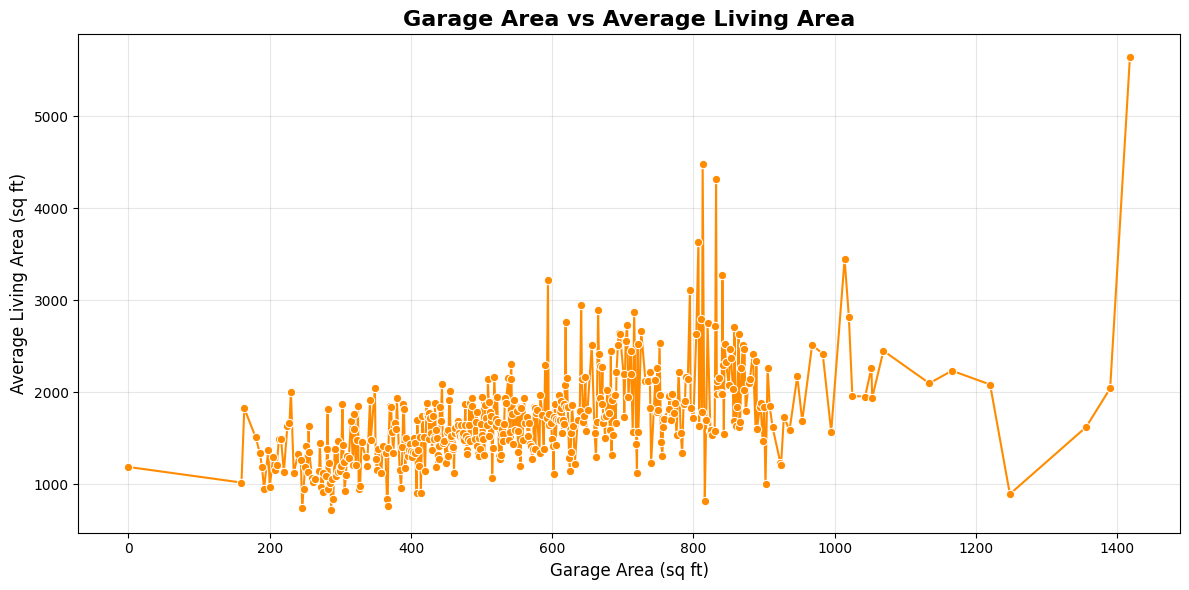

In [19]:
garage_living = (
    df.groupby('GarageArea')['GrLivArea']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=garage_living,
    x='GarageArea',
    y='GrLivArea',
    marker='o',
    color='darkorange'
)

plt.title(
    'Garage Area vs Average Living Area',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Garage Area (sq ft)', fontsize=12)
plt.ylabel('Average Living Area (sq ft)', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 💡 Insight 4: Houses with Larger Garage Areas Generally Command Higher Selling Prices

**Observation:**

The average selling price increased as the garage area increased, indicating that houses with larger garages tend to have higher market values. Larger garages are often associated with premium properties that offer additional convenience and storage space.

**Business Insight:**

The supporting analysis shows that houses with larger garage areas also have **larger average living areas**, suggesting that spacious garages are typically part of larger homes. Buyers are therefore paying for the overall size and functionality of the property rather than the garage alone.

**Recommendation:**

Homebuyers should consider garage space as one of the indicators of a property's overall value, especially for families requiring additional parking or storage. Real estate developers can enhance property value by designing homes with adequately sized garages that complement the overall living space.

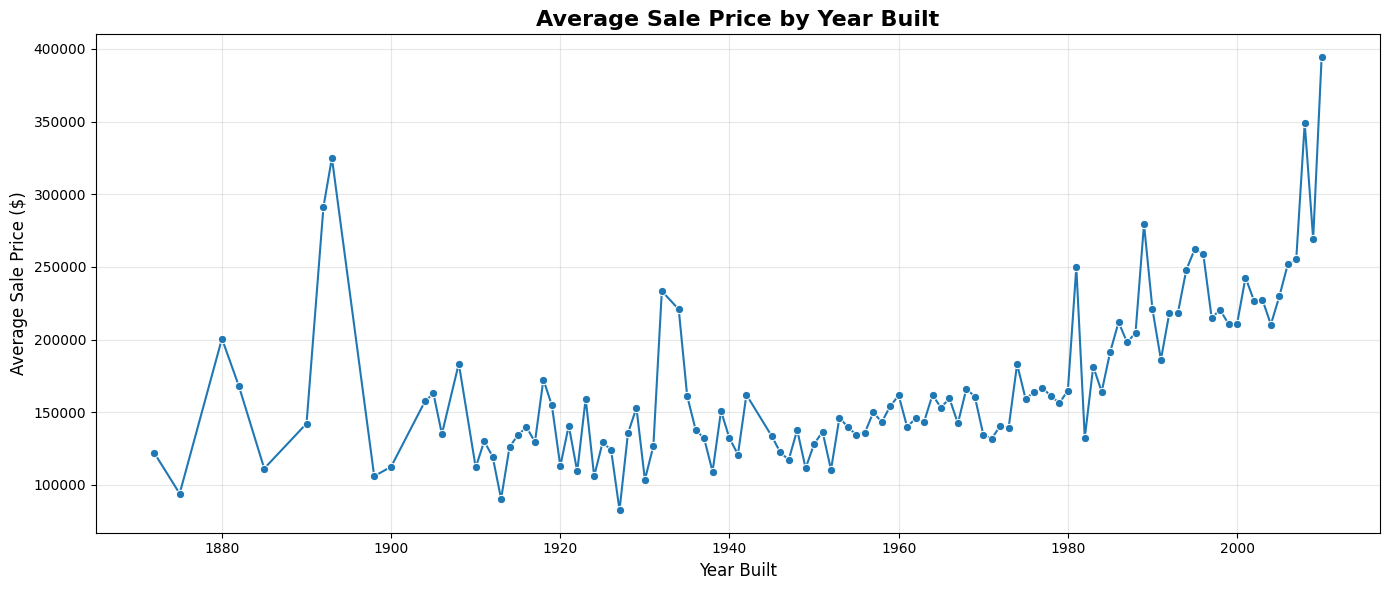

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

year_price = (
    df.groupby('YearBuilt')['SalePrice']
      .mean()
      .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=year_price,
    x='YearBuilt',
    y='SalePrice',
    marker='o'
)

plt.title(
    'Average Sale Price by Year Built',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year Built', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

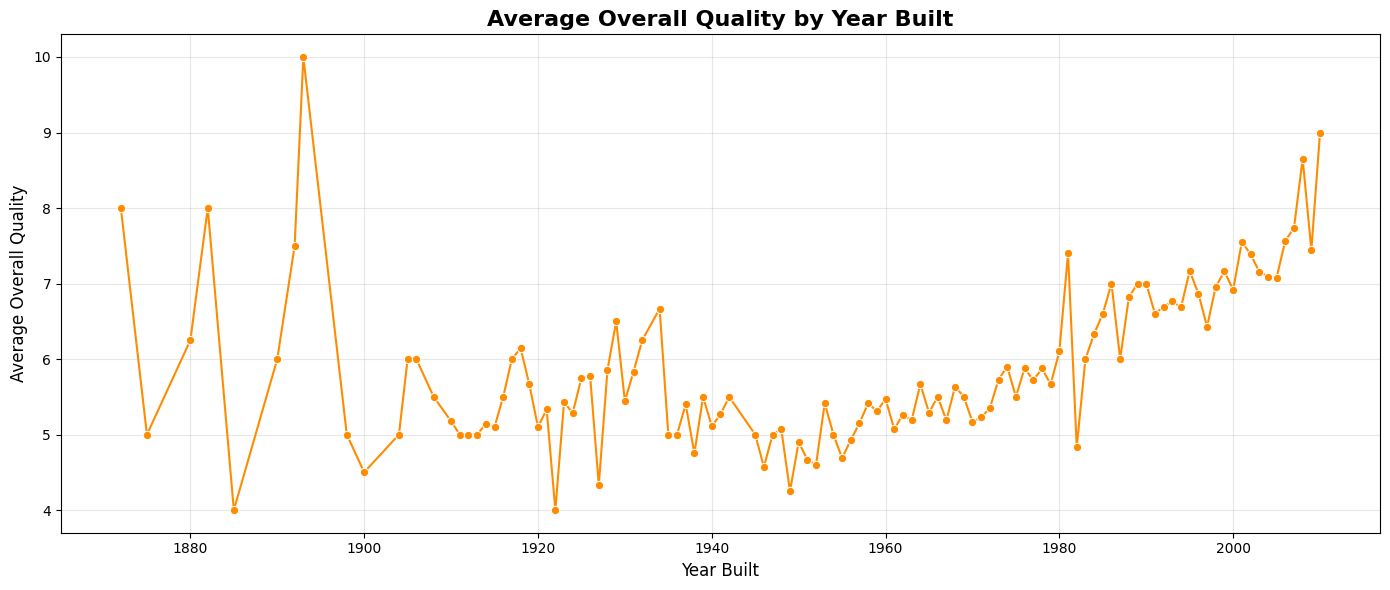

In [21]:
year_quality = (
    df.groupby('YearBuilt')['OverallQual']
      .mean()
      .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=year_quality,
    x='YearBuilt',
    y='OverallQual',
    marker='o',
    color='darkorange'
)

plt.title(
    'Average Overall Quality by Year Built',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year Built', fontsize=12)
plt.ylabel('Average Overall Quality', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 💡 Insight 5: Newer Houses Generally Achieve Higher Selling Prices

**Observation:**

The analysis indicates that houses built in more recent years generally have higher average selling prices than older properties. This suggests that buyers are willing to pay a premium for newer homes.

**Business Insight:**

The supporting analysis shows that newer houses also have **higher average overall quality ratings**, indicating that modern construction standards, improved materials, and updated designs contribute to their higher market value. Buyers often prefer newer homes because they require less maintenance and offer contemporary features.

**Recommendation:**

Homebuyers should evaluate both the **age** and **overall quality** of a property before making a purchase decision. Real estate developers can maximize property value by maintaining high construction standards and incorporating modern designs that align with current buyer preferences.

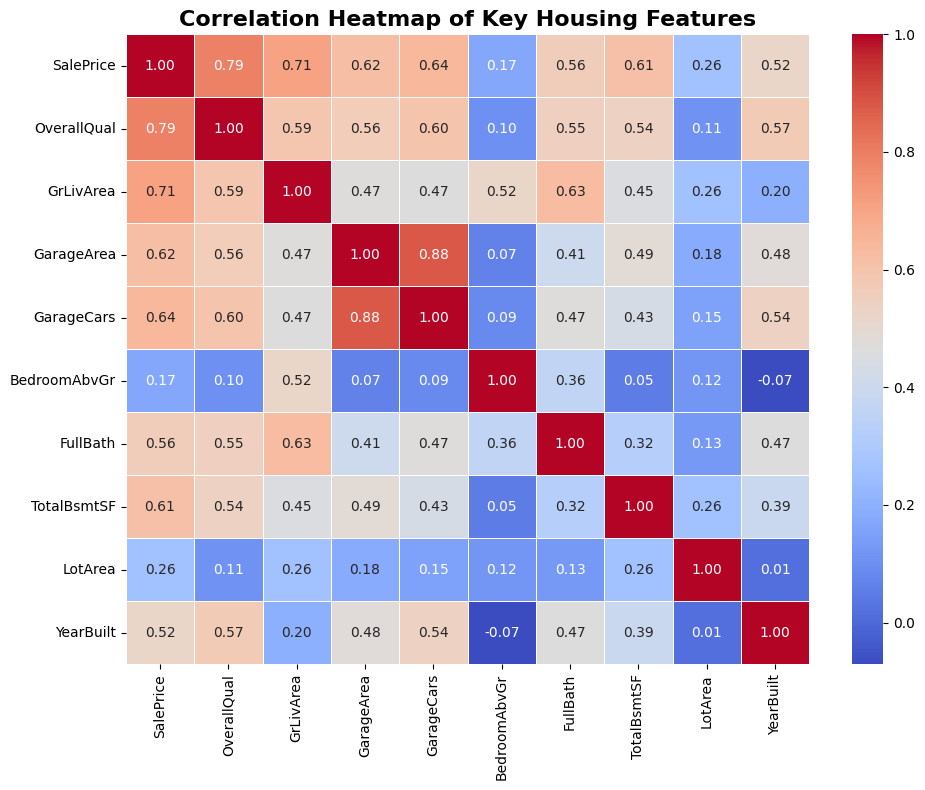

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[
    [
        'SalePrice',
        'OverallQual',
        'GrLivArea',
        'GarageArea',
        'GarageCars',
        'BedroomAbvGr',
        'FullBath',
        'TotalBsmtSF',
        'LotArea',
        'YearBuilt'
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap of Key Housing Features',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

## 📊 Correlation Heatmap Analysis

The correlation heatmap highlights the relationships among the key numerical variables influencing house prices.

### Key Observations

- **Overall Quality** exhibited the strongest positive correlation with **Sale Price**, making it one of the most influential factors affecting property value.
- **Ground Living Area**, **Garage Area**, **Garage Capacity**, and **Total Basement Area** also showed strong positive relationships with selling price, indicating that larger and more spacious homes generally command higher market values.
- **Year Built** demonstrated a positive relationship with both **Overall Quality** and **Sale Price**, suggesting that newer homes typically offer better construction quality and achieve higher prices.
- **Bedroom Count** showed a comparatively weaker relationship with selling price than overall living area, indicating that buyers value spacious layouts more than simply having additional bedrooms.

Overall, the correlation analysis supports the business insights derived throughout the exploratory analysis and confirms that **construction quality, living space, garage facilities, and property age are among the primary drivers of house prices.**